In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
grant = pd.read_csv('grant_opportunity_details.csv')
grant.shape


(2000, 68)

In [2]:
grant.head()

,opportunity_id,funding_opportunity_number,funding_opportunity_title,opportunity_category,opportunity_category_explanation,expected_number_of_awards,cost_sharing_or_matching_requirement,version,posted_date,last_updated_date,...,category_income_security,category_info,category_law,category_natural_resources,category_opportunity_zone,category_regional_development,category_science,category_transportation,category_other,category_explanation
0,40112,DHS-FEMACAPSSSE-08-001,Community Assistance Program State Support Ser...,Discretionary,NaN,52.0,True,1,2007-11-28,2007-11-28,...,False,False,False,False,False,False,False,False,True,The purpose of the Community Assistance Progra...
1,40113,DHS-FEMACAPSSSE-08-001,Community Assistance Program State Support Ser...,Discretionary,NaN,52.0,True,1,2007-11-28,2007-11-28,...,False,False,False,False,False,False,False,False,True,The purpose of the Community Assistance Progra...
2,42048,FWS-R4-FLEXFUND,Southeast Region Flex Funds,Discretionary,NaN,25.0,False,3,2008-06-17,2008-06-18,...,False,False,False,True,False,False,False,False,False,NaN
3,42423,306-08-027-RFI,Alternative Development Program,Discretionary,NaN,1.0,False,1,2008-07-22,2008-07-22,...,False,False,False,False,False,False,False,False,False,NaN
4,45657,04-563,Developing Country Collaborations in Plant Gen...,Discretionary,NaN,NaN,True,2,2004-03-22,2009-03-03,...,False,False,False,False,False,False,True,False,False,NaN


In [21]:
grant.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 69 columns):
 #   Column                                                               Non-Null Count  Dtype         
---  ------                                                               --------------  -----         
 0   opportunity_id                                                       2000 non-null   int64         
 1   funding_opportunity_number                                           2000 non-null   object        
 2   funding_opportunity_title                                            2000 non-null   object        
 3   opportunity_category                                                 2000 non-null   object        
 4   opportunity_category_explanation                                     53 non-null     object        
 5   expected_number_of_awards                                            619 non-null    float64       
 6   cost_sharing_or_matching_requirement            

In [8]:
grant.describe(include="all")

,opportunity_id,funding_opportunity_number,funding_opportunity_title,opportunity_category,opportunity_category_explanation,expected_number_of_awards,cost_sharing_or_matching_requirement,version,posted_date,last_updated_date,...,category_income_security,category_info,category_law,category_natural_resources,category_opportunity_zone,category_regional_development,category_science,category_transportation,category_other,category_explanation
count,2000.000000,2000,2000,2000,53,619.000000,2000,2000.000000,2000,2000,...,2000,2000,2000,2000,2000,2000,2000,2000,2000,157
unique,NaN,1999,1976,5,41,NaN,2,NaN,680,538,...,2,2,2,2,2,2,2,2,2,124
top,NaN,DHS-FEMACAPSSSE-08-001,Community Assistance Program State Support Ser...,Discretionary,CategoryExplanation,NaN,False,NaN,2023-02-14,2023-05-20,...,False,False,False,False,False,False,False,False,False,Regional planning and local technical assistance
freq,NaN,2,2,1940,9,NaN,1786,NaN,29,76,...,1823,1999,1988,1920,1994,1995,1508,1985,1871,11
mean,336497.566500,NaN,NaN,NaN,NaN,1692.786753,NaN,2.458500,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,35768.083032,NaN,NaN,NaN,NaN,40193.585985,NaN,3.711087,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,40112.000000,NaN,NaN,NaN,NaN,0.000000,NaN,1.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,335731.500000,NaN,NaN,NaN,NaN,3.000000,NaN,1.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,345324.500000,NaN,NaN,NaN,NaN,11.000000,NaN,1.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,349096.250000,NaN,NaN,NaN,NaN,30.000000,NaN,2.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


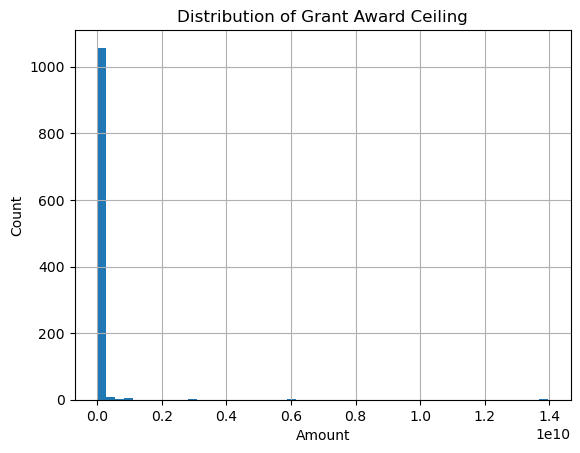

In [9]:
amount_col = "award_ceiling"  # adjust if needed

grant[amount_col].dropna().hist(bins=50)
plt.title("Distribution of Grant Award Ceiling")
plt.xlabel("Amount")
plt.ylabel("Count")
plt.show()

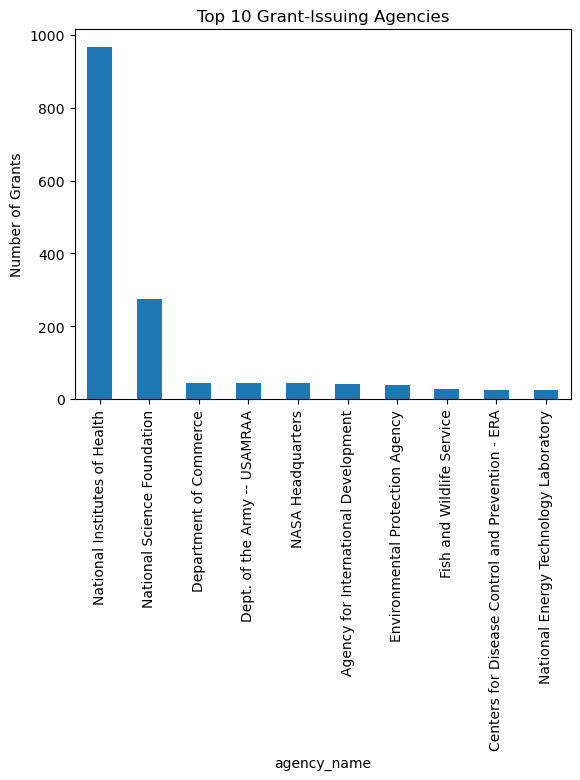

In [12]:
grant["agency_name"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Grant-Issuing Agencies")
plt.ylabel("Number of Grants")
plt.show()

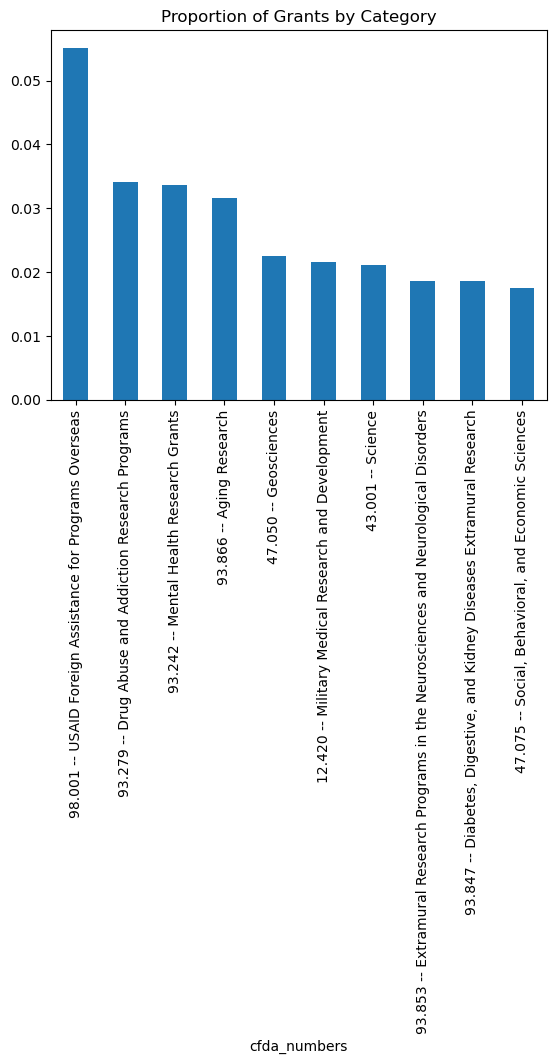

In [15]:
grant["cfda_numbers"].value_counts(normalize=True).head(10).plot(kind="bar")
plt.title("Proportion of Grants by Category")
plt.show()

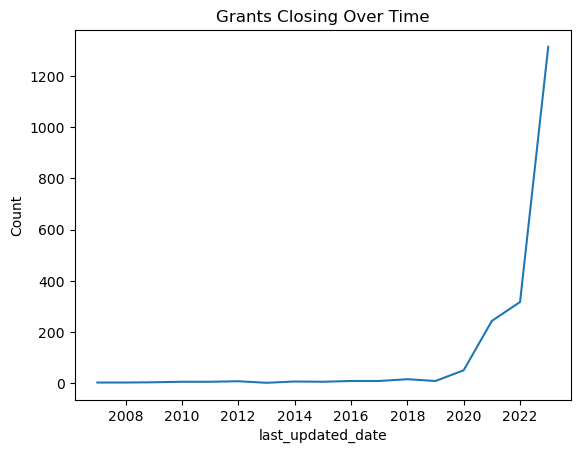

In [18]:
grant["last_updated_date"] = pd.to_datetime(grant["last_updated_date"], errors="coerce")

grant["last_updated_date"].dt.year.value_counts().sort_index().plot(kind="line")
plt.title("Grants Closing Over Time")
plt.ylabel("Count")
plt.show()

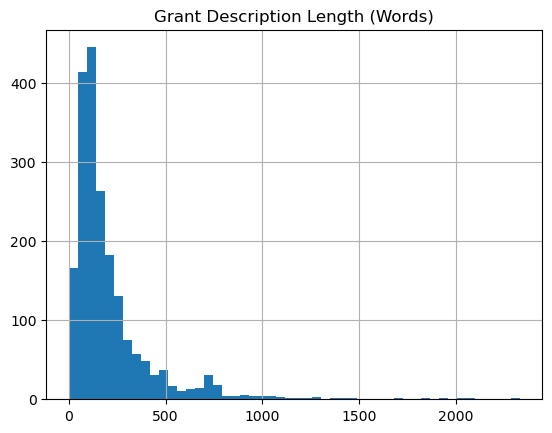

In [19]:
grant["desc_length"] = grant["description"].astype(str).str.split().str.len()

grant["desc_length"].hist(bins=50)
plt.title("Grant Description Length (Words)")
plt.show()

In [20]:
grant.groupby("agency_name")["desc_length"].mean().sort_values(ascending=False).head(10)

agency_name
U.S. Mission to Guinea                          2297.000000
U.S. Mission to Switzerland                     1861.000000
U.S. Mission to Cape Verde                      1452.000000
Africa Regional Services                         919.000000
Advanced Research Projects Agency Energy         904.000000
National Archives and Records Administration     767.333333
U.S. Mission to Spain                            760.500000
NASA Headquarters                                732.697674
Construction of State Home Facilities            723.000000
Dept. of the Army -- USAMRAA                     699.318182
Name: desc_length, dtype: float64